# Protein folding (Baldo's version)
This follows everything Baldo teached and said the exam was going to be about. It manages everything, downloads the databases, pdb files and run's the programs. In each cell there are instructions for fine tunning the parameters of the programs, but the default ones should be good enough for the exam.

## PSI-BLAST and HMM
This notebook is to create a pipeline for Baldo's exam lol.

In [1]:
# Import the refactored pipeline modules
from src.pipeline import HomologyPipeline
from src.Setup.setup import Setup
from src.Setup.preprocessing import TargetPreprocessor
from src.Homology.retrieve import TemplateRetriever
from src.Homology.domains import TemplateProcessor
from src.Homology.superimpose import SuperimpositionVisualizer
from src.UI.app import CoverageVisualizer, DomainVisualizer, run_dssp

import pandas as pd
import matplotlib.pyplot as plt
import py3Dmol

# Setup directories and databases (skips download if already exists)
setup = Setup(skip_databases=True, clear_temp=False)
print("Setup complete!")
print(f"Working directory: {setup.base_dir}")

Setup complete!
Working directory: /Users/manueldelabra/Documents/Master/SBI/AlphaBald


In [2]:
# Load target sequence (auto-detects FASTA or PDB in target/ folder)
target = TargetPreprocessor(target_dir="target")
print(f"Target: {target.name}")
print(f"Length: {len(target.sequence)} aa")
print(f"Source: {target.source_type}")
target.sequence[:50]

Target: Test
Length: 217 aa
Source: fasta


'MEAIAKYDFKATADDELSFKRGDILKVLNEECDQNWYKAELNGKDGFIPK'

In [3]:
# View target sequence
print(f"Sequence: {target.sequence[:60]}...")
print(f"Full length: {len(target.sequence)} amino acids")

Sequence: MEAIAKYDFKATADDELSFKRGDILKVLNEECDQNWYKAELNGKDGFIPKNYIEMKPHPW...
Full length: 217 amino acids


In [4]:
# View target info as dictionary
target.to_dict()

{'name': 'Test',
 'sequence': 'MEAIAKYDFKATADDELSFKRGDILKVLNEECDQNWYKAELNGKDGFIPKNYIEMKPHPWFFGKIPRAKAEEMLSKQRHDGAFLIRESESAPGDFSLSVKFGNDVQHFKVLRDGAGKYFLWVVKFNSLNELVDYHRSTSVSRNQQIFLRDIEQVPQQPTYVQALFDFDPQEDGELGFRRGDFIHVMDNSDPNWWKGACHGQTGMFPRNYVTPVNRNV',
 'length': 217,
 'source_type': 'fasta',
 'file_path': 'target/target.fa',
 'resolution': None}

# Turururu
Okay, since Baldo always changes the exam, this is a pipeline that runs the big steps of the exam, there is a description of the steps in the notebook, but if you have any questions, please ask me!

The big steps are:
1. Retrieve homologs using PSI-BLAST and HMMER
- 2. Create a multiple sequence alignment (MSA) of the homologs
- 3. Create a template-based model using MODELLER
- 4. Create a template-free model using AlphaFold2

# 1. Retrieve homologs using PSI-BLAST and HMMER
There are three ways to use this, since Baldo can give the sequence in different formats, you can either:
- 1. Modify the `target_sequence` variable in the notebook, and then run the cells, this is the most straightforward way, but it can be a bit messy if you have a long sequence.
- 2. If Baldo gives you a fasta file, you can put it in the `target` folder, and then read it from there, this is a bit more organized, but it requires a bit more work.
- 3. If Baldo gives you a pdb file, you can put it in the target folder, and change the flag `use_pdb` to True, this is the most organized way, but it requires a bit more work.

In [5]:
# This is a placeholder sequence, it's easier to replace here, but, it can also be used as a fasta inside the target folder, and then read it from there, but I think this is more straightforward for now.
TARGET_SEQUENCE= "MEAIAKYDFKATADDELSFKRGDILKVLNEECDQNWYKAELNGKDGFIPKNYIEMKPHPWFFGKIPRAKAEEMLSKQRHDGAFLIRESESAPGDFSLSVKFGNDVQHFKVLRDGAGKYFLWVVKFNSLNELVDYHRSTSVSRNQQIFLRDIEQVPQQPTYVQALFDFDPQEDGELGFRRGDFIHVMDNSDPNWWKGACHGQTGMFPRNYVTPVNRNV"

Retrieve will run psi-blast and the HMM using the fasta sequence of the target protein.
You need to put the target fasta sequence in the `target/` folder, the name doesn't matter but there should be only one file!. 
The output of psi-blast will be stored in `temp/target_psiblast.out` and the HMM output will be stored in `temp/target_hmm.out`.

This is ordered based on the Bitscore and E-value

In [6]:
# Search for template structures using PSI-BLAST and HMMER
retriever = TemplateRetriever(
    target_path="target/target.fa",
    e_value_threshold=1e-5,
    num_iterations=5,
    num_hits=20,
    run_hmmer=True,
    verbose=True
)

# Show top templates sorted by identity
retriever.homologs.sort_values("Identity", ascending=False).head(10)

Starting template search pipeline...
Step 1: Building PSSM from SwissProt search...
  Running PSI-BLAST against SwissProt...
Step 2: Searching PDB with PSSM...
  Running PSI-BLAST against PDB...
Step 3: Creating MSA and searching PDB...
  Running ClustalW alignment...
  Running MSA-based PSI-BLAST...
Step 4: Running jackhmmer search...
  Running jackhmmer...
Step 5: Building HMM profile...
  Running hmmbuild...
Ranking all template hits...
Found 606 unique templates.


,PDB_ID,Bitscore,E-value,Identity,Query_Coverage,Query_Start,Query_End,Subject_Start,Subject_End,Query_Length,Protein Name,Organism,Origin
0,8DGO_A,167.0,1.370000e-51,100.0,100,1,217,3,219,217,GROWTH FACTOR RECEPTOR BOUND PROTEIN 2,Homo sapiens,PSSM-based Search
11,2AOA_A,127.0,2.910000e-37,100.0,46,55,153,1,99,217,GROWTH FACTOR RECEPTOR-BOUND PROTEIN 2,Homo sapiens,MSA-based Search
22,6ICG_A,119.0,2.400000e-34,100.0,43,60,152,3,95,217,GROWTH FACTOR RECEPTOR-BOUND PROTEIN 2,Homo sapiens,MSA-based Search
85,1GFC_A,73.5,6.730000e-17,100.0,52,160,215,4,59,217,GROWTH FACTOR RECEPTOR-BOUND PROTEIN 2,Homo sapiens,PSSM-based Search
20,7MPH_A,121.0,5.610000e-35,100.0,43,59,152,2,95,217,GROWTH FACTOR RECEPTOR-BOUND PROTEIN 2,Homo sapiens,MSA-based Search
17,1CJ1_A,123.0,7.050000e-36,100.0,44,57,152,1,96,217,PROTEIN (GROWTH FACTOR RECEPTOR-BOUND PROTEIN 2),Homo sapiens,MSA-based Search
61,1GCQ_A,76.6,4.240000e-18,100.0,53,160,217,4,61,217,GROWTH FACTOR RECEPTOR-BOUND PROTEIN 2,Homo sapiens,PSSM-based Search
15,1ZFP_E,124.0,2.470000e-36,100.0,45,56,153,1,98,217,GROWTH FACTOR RECEPTOR BINDING PROTEIN,Homo sapiens,MSA-based Search
13,6VK2_A,126.0,5.940000e-37,100.0,44,55,150,1,96,217,GROWTH FACTOR RECEPTOR-BOUND PROTEIN 2,Homo sapiens,MSA-based Search
1,1GRI_A,167.0,1.810000e-51,100.0,100,1,217,1,217,217,GROWTH FACTOR BOUND PROTEIN 2,Homo sapiens,PSSM-based Search


# Obtener los dominios de la proteína objetivo, importante al parecer

# Select the number of templates to visualize.
This is important so it can show you the domains of the templates, coverage and superimposition of the templates. Change the value of the variable `num_templates` to select the number of templates to visualize in the next cell. The default value is 5, but you can change it to any number you want (but not too high, otherwise it will be hard to visualize).
Later you can select the specific templates you want to use for the Modeling part of the exam, but for now just select the number of templates you want to visualize.

In [7]:
num_templates = 5

# Domains and superimposition of the templates
This is important to see the coverage of the templates, if they cover the same domains or different ones, and if they have the same domains as the target protein. This will help you to select the templates for the Modeling part of the exam.

In [8]:
# Download and analyze top templates
template_proc = TemplateProcessor(
    homologs=retriever.homologs,
    num_templates=num_templates,
    target_path="target/target.fa",
    verbose=True
)

print(f"\nProcessed {len(template_proc.pdb_sequences)} templates")
print(f"Domain data available for {len(template_proc.domain_data)} templates")

Extracting template sequences...
Creating alignment FASTA...
Fetching domain annotations...
  8DGO_A: 20 domain(s)
  1GRI_A: 20 domain(s)
  1BMB_A: 6 domain(s)
  1BM2_A: 6 domain(s)
  1FYR_A: 6 domain(s)
Searching target domains with HMM...
  Target: 11 domain(s) found
    - SH3_10 (PF17902.8): 3-49
    - SH3_1 (PF00018.35): 4-50
    - SH3_9 (PF14604.13): 5-54
    - SH3_2 (PF07653.24): 5-54
    - SH3_1 (PF00018.35): 54-65
    - SH2 (PF00017.31): 60-135
    - SH3_10 (PF17902.8): 133-153
    - SH3_10 (PF17902.8): 153-195
    - SH3_2 (PF07653.24): 160-212
    - SH3_1 (PF00018.35): 162-206
    - SH3_9 (PF14604.13): 163-211

Processed 5 templates
Domain data available for 5 templates


In [9]:
# List all template PDB IDs
template_pdb_ids = retriever.homologs.head(num_templates)["PDB_ID"].tolist()
print("Selected templates for modeling:")
for i, pdb_id in enumerate(template_pdb_ids, 1):
    print(f"  {i}. {pdb_id}")

Selected templates for modeling:
  1. 8DGO_A
  2. 1GRI_A
  3. 1BMB_A
  4. 1BM2_A
  5. 1FYR_A


In [10]:
# HMM-based domain search for target (NEW FEATURE)
# The target domains are now automatically searched using Pfam HMM database
print("Target domains (detected via HMM/Pfam):")
print("=" * 50)
for i, domain in enumerate(template_proc.target_domains, 1):
    print(f"{i}. {domain['name']} ({domain['id']})")
    print(f"   Position: {domain['start']}-{domain['end']}")
    print(f"   E-value: {domain['e_value']:.2e}")
    print()

Target domains (detected via HMM/Pfam):
1. SH3_10 (PF17902.8)
   Position: 3-49
   E-value: 1.10e-07

2. SH3_1 (PF00018.35)
   Position: 4-50
   E-value: 6.20e-36

3. SH3_9 (PF14604.13)
   Position: 5-54
   E-value: 3.70e-32

4. SH3_2 (PF07653.24)
   Position: 5-54
   E-value: 2.40e-27

5. SH3_1 (PF00018.35)
   Position: 54-65
   E-value: 6.20e-36

6. SH2 (PF00017.31)
   Position: 60-135
   E-value: 3.30e-26

7. SH3_10 (PF17902.8)
   Position: 133-153
   E-value: 1.10e-07

8. SH3_10 (PF17902.8)
   Position: 153-195
   E-value: 1.10e-07

9. SH3_2 (PF07653.24)
   Position: 160-212
   E-value: 2.40e-27

10. SH3_1 (PF00018.35)
   Position: 162-206
   E-value: 6.20e-36

11. SH3_9 (PF14604.13)
   Position: 163-211
   E-value: 3.70e-32



In [11]:
# Domain visualization with target domains and DSSP secondary structure
from src.UI.app import DomainVisualizer

# Get target data with domains (now includes HMM-detected domains)
target_data = template_proc.get_target_data()
print(f"Target: {target_data[0]}")
print(f"Target domains found: {len(target_data[2])}")
for d in target_data[2][:5]:  # Show first 5
    print(f"  - {d['name']} ({d.get('id', 'N/A')}): {d['start']}-{d['end']}")

# Get template domain data
template_data_list = template_proc.get_template_data_list()

# Show domain visualization WITH target domains and DSSP secondary structure
domain_viewer = DomainVisualizer(
    target_data,  # Now includes target domains from HMM
    template_data_list,
    show_secondary_structure=True,  # Enable DSSP
    templates_dir="Templates"
)
domain_viewer.show()

Target: Test
Target domains found: 11
  - SH3_10 (PF17902.8): 3-49
  - SH3_1 (PF00018.35): 4-50
  - SH3_9 (PF14604.13): 5-54
  - SH3_2 (PF07653.24): 5-54
  - SH3_1 (PF00018.35): 54-65
DSSP failed: File type must be PDB, mmCIF or DSSP
DSSP failed: File type must be PDB, mmCIF or DSSP
DSSP failed: File type must be PDB, mmCIF or DSSP
DSSP failed: File type must be PDB, mmCIF or DSSP
DSSP failed: File type must be PDB, mmCIF or DSSP


# Domains of the templates
This is important to see the coverage of the templates, if they cover the same domains or different ones, and if they have the same domains as the target protein. This will help you to select the templates for the Modeling part of the exam.

## Visualize the Do

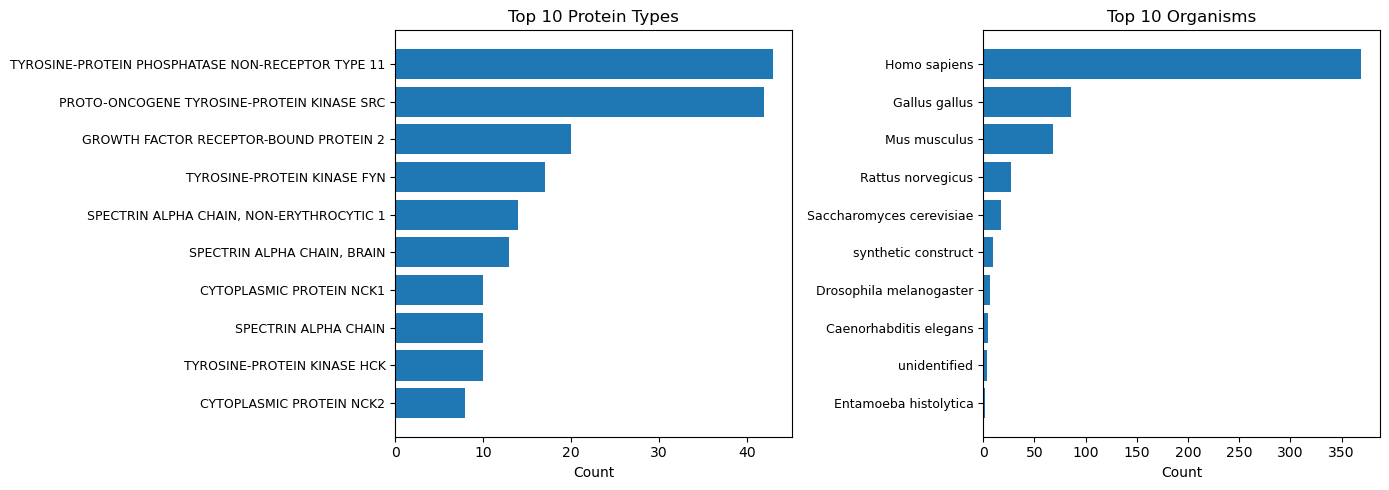

In [12]:
# Plot distribution of protein types and organisms
retriever.plot_homologs(top_n=10)

# Select the number of templates to visualize.
Change the value of the variable `num_templates` to select the number of templates to visualize in the next cell. The default value is 5, but you can change it to any number you want (but not too high, otherwise it will be hard to visualize).
Later you can select the specific templates you want to use for the Modeling part of the exam, but for now just select the number of templates you want to visualize.

In [13]:
# ============================================================
# SUPERIMPOSITION VISUALIZER - py3Dmol visualization
# ============================================================
from src.Homology.superimpose import SuperimpositionVisualizer, get_ca_mapping
from pathlib import Path

# First, align the templates
print("Aligning templates with ClustalW...")
aligned_file = template_proc.align_templates()
print(f"Alignment saved to: {aligned_file}")

# Create the SuperimpositionVisualizer
print("\nInitializing SuperimpositionVisualizer...")
sup_viz = SuperimpositionVisualizer(
    alignment_file=str(aligned_file),
    templates_dir="Templates",
    output_dir="Superimposed"
)

# Get template IDs from our selected templates
template_ids = retriever.homologs.head(num_templates)["PDB_ID"].tolist()
print(f"\nTemplates to superimpose: {template_ids}")

Aligning templates with ClustalW...
Alignment saved to: Alignments/aligned_templates.fasta

Initializing SuperimpositionVisualizer...

Templates to superimpose: ['8DGO_A', '1GRI_A', '1BMB_A', '1BM2_A', '1FYR_A']


In [14]:
# Superimpose and save structures to Superimposed/ directory
print("Superimposing structures...")
results = sup_viz.superimpose_and_save(template_ids)

print(f"\n{len(results)} structures superimposed and saved:")
for pdb_id, (path, rmsd) in results.items():
    print(f"  {pdb_id}: {path.name} (RMSD: {rmsd:.2f} Å)")

Superimposing structures...
  1GRI_A: RMSD = 13.21 Å
  1BMB_A: RMSD = 1.15 Å
  1BM2_A: RMSD = 1.66 Å
  1FYR_A: RMSD = 12.13 Å

5 structures superimposed and saved:
  8DGO_A: 8DGO_A_ref.pdb (RMSD: 0.00 Å)
  1GRI_A: 1GRI_A_superimposed.pdb (RMSD: 13.21 Å)
  1BMB_A: 1BMB_A_superimposed.pdb (RMSD: 1.15 Å)
  1BM2_A: 1BM2_A_superimposed.pdb (RMSD: 1.66 Å)
  1FYR_A: 1FYR_A_superimposed.pdb (RMSD: 12.13 Å)


In [15]:
# Interactive coverage visualization (fixed)
# Reload the module to get the fixed version
import importlib
import src.UI.app
importlib.reload(src.UI.app)
from src.UI.app import CoverageVisualizer, DomainVisualizer

# Create coverage visualizer
print("Creating CoverageVisualizer...")
coverage_viz = CoverageVisualizer(retriever.homologs, number_of_templates=3)
coverage_viz.show()

Creating CoverageVisualizer...
Creating sequence alignment...
CoverageVisualizer ready with 3 templates


In [16]:
# ============================================================
# py3Dmol VISUALIZATION with match/mismatch coloring
# ============================================================
# Color scheme:
#   - GREEN: Matching residues
#   - RED: Mismatching residues  
#   - GRAY: Gaps in alignment

print("Creating py3Dmol visualization with alignment coloring...")
view = sup_viz.visualize_py3dmol(template_ids[:3], width=1200, height=900)

# Display the viewer
if view:
    print("\nColor Legend:")
    print("  Green = Matching residues with target")
    print("  Red = Mismatching residues")
    print("  Gray = Gaps in alignment")
    view.show()

Creating py3Dmol visualization with alignment coloring...

Color Legend:
  Green = Matching residues with target
  Red = Mismatching residues
  Gray = Gaps in alignment


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [18]:
# Get alignment statistics for each template
print("Alignment Statistics:")
print("-" * 60)
for pdb_id in template_ids:
    stats = sup_viz.get_alignment_stats(pdb_id)
    if stats:
        print(f"\n{pdb_id}:")
        print(f"  Matches:    {stats['matches']:4d} residues")
        print(f"  Mismatches: {stats['mismatches']:4d} residues")
        print(f"  Gaps:       {stats['gaps']:4d} residues")
        print(f"  Identity:   {stats['identity']:6.1f}%")
        print(f"  Coverage:   {stats['coverage']:4d} aligned positions")

Alignment Statistics:
------------------------------------------------------------

8DGO_A:
  Matches:     217 residues
  Mismatches:    0 residues
  Gaps:          2 residues
  Identity:    100.0%
  Coverage:    217 aligned positions

1GRI_A:
  Matches:     211 residues
  Mismatches:    6 residues
  Gaps:          0 residues
  Identity:     97.2%
  Coverage:    217 aligned positions

1BMB_A:
  Matches:      98 residues
  Mismatches:    0 residues
  Gaps:          0 residues
  Identity:    100.0%
  Coverage:     98 aligned positions

1BM2_A:
  Matches:      98 residues
  Mismatches:    0 residues
  Gaps:          0 residues
  Identity:    100.0%
  Coverage:     98 aligned positions

1FYR_A:
  Matches:      95 residues
  Mismatches:    0 residues
  Gaps:          0 residues
  Identity:    100.0%
  Coverage:     95 aligned positions


In [19]:
# PDB files are already downloaded by TemplateProcessor
print("Downloaded PDB files:")
for pdb_id, path in template_proc.pdb_files.items():
    print(f"  {pdb_id}: {path}")

Downloaded PDB files:
  8DGO: Templates/pdb8dgo.ent
  1GRI: Templates/pdb1gri.ent
  1BMB: Templates/pdb1bmb.ent
  1BM2: Templates/pdb1bm2.ent
  1FYR: Templates/pdb1fyr.ent


In [20]:
# Simple coverage calculation example
target_length = len(target.sequence)

# Calculate total coverage from top templates
top_5 = retriever.homologs.head(5)
all_positions = set()
for _, row in top_5.iterrows():
    start = int(row.get('Query_Start', 1))
    end = int(row.get('Query_End', target_length))
    all_positions.update(range(start, end + 1))

coverage = (len(all_positions) / target_length) * 100
print(f"Combined coverage from top 5 templates: {coverage:.1f}%")
print(f"Covered positions: {len(all_positions)}/{target_length}")

Combined coverage from top 5 templates: 100.0%
Covered positions: 217/217


In [24]:
# MODELLER Setup
from modeller import *
from modeller.automodel import *

log.minimal()
env = Environ()

# Set directories for input atom files
env.io.atom_files_directory = ['Templates/', '.']

print("MODELLER environment ready")
print("Templates available:", list(template_proc.pdb_files.keys()))


                         MODELLER 10.8, 2025/11/04, r13157

     PROTEIN STRUCTURE MODELLING BY SATISFACTION OF SPATIAL RESTRAINTS


                     Copyright(c) 1989-2025 Andrej Sali
                            All Rights Reserved

                             Written by A. Sali
                               with help from
              B. Webb, M.S. Madhusudhan, M-Y. Shen, G.Q. Dong,
          M.A. Marti-Renom, N. Eswar, F. Alber, M. Topf, B. Oliva,
             A. Fiser, R. Sanchez, B. Yerkovich, A. Badretdinov,
                     F. Melo, J.P. Overington, E. Feyfant
                 University of California, San Francisco, USA
                    Rockefeller University, New York, USA
                      Harvard University, Cambridge, USA
                   Imperial Cancer Research Fund, London, UK
              Birkbeck College, University of London, London, UK


Kind, OS, HostName, Kernel, Processor: 4, Darwin Manuels-MacBook-Pro.local 25.3.0 arm64
Date and time of comp